In [1]:
import torch
from matplotlib import pyplot as plt
from torchvision.utils import make_grid
from diffusion.approaches.matching.alphas_betas import LinearAlpha, LinearBeta
from diffusion.approaches.matching.prob_paths import GaussianCondProbPath
from diffusion.data.mnist_sampleable import MNISTSampleable
from diffusion.architectures.res_unet import ResUnet
from diffusion.approaches.matching.flow_generator import FlowGenerator, ScoreGenerator

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
sampeable = MNISTSampleable(train=True)

path = GaussianCondProbPath(
    p_data=sampeable,
    p_simple_shape=sampeable.shape,
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

backbone = ResUnet(
    in_channels=1,
    channels=[16, 32, 64],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)

backbone.load_state_dict(torch.load("./models/backbone_flow.pt"))

<All keys matched successfully>

100%|██████████| 9/9 [00:00<00:00, 20.71it/s]


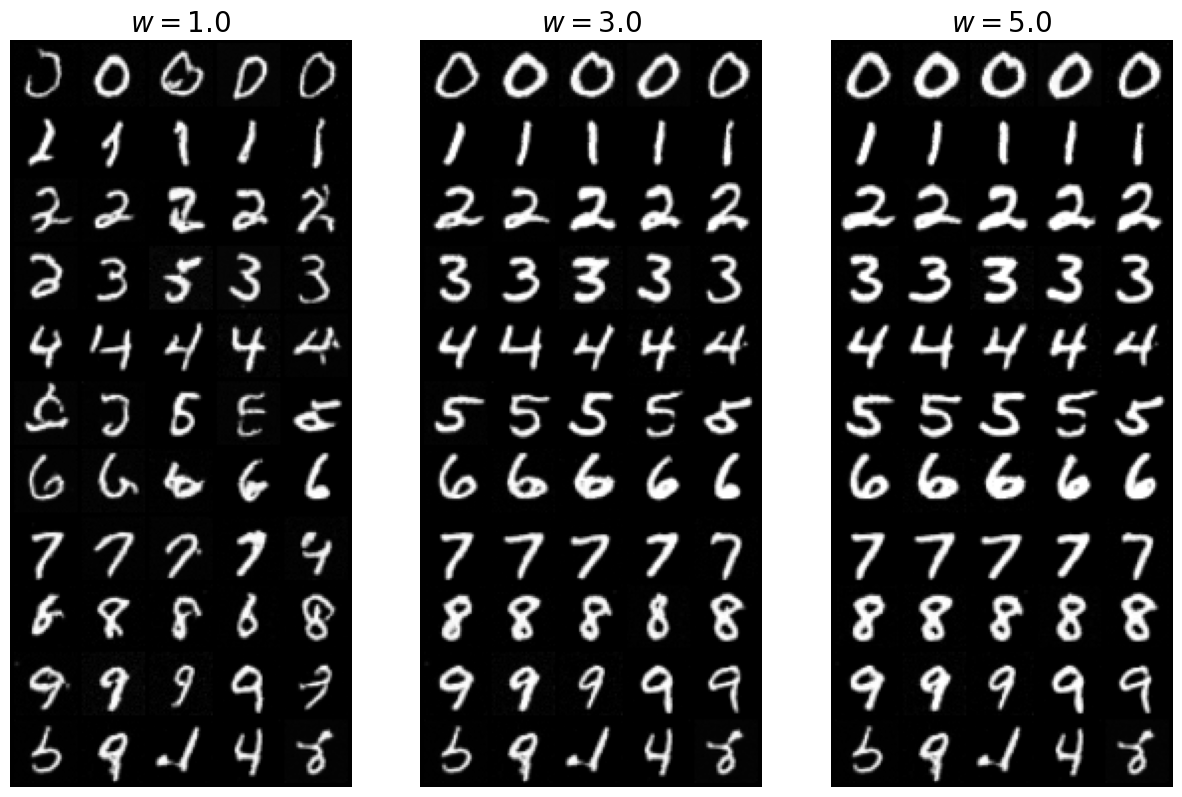

In [4]:
num_timesteps = 10
samples_per_class = 5
guidance_scales = [1.0, 3.0, 5.0]

y = (
    torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    .repeat_interleave(samples_per_class)
    .to(device)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(guidance_scales),
    figsize=(samples_per_class * len(guidance_scales), 10),
)

x0, _ = path.p_simple.sample(y.shape[0])
# (num_samples, 1, 32, 32)

for idx, w in enumerate(guidance_scales):
    flow_generator = FlowGenerator(
        path=path,
        backbone=backbone,
        num_timesteps=num_timesteps,
        null_class=sampeable.num_classes,
        guidance_scale=w,
        device=device,
    )

    x1 = flow_generator.generate(y, x0)

    grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(-1, 1))
    axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    axes[idx].axis("off")
    axes[idx].set_title(f"$w={w:.1f}$", fontsize=20)

plt.show()

100%|██████████| 9/9 [00:00<00:00, 10.73it/s]


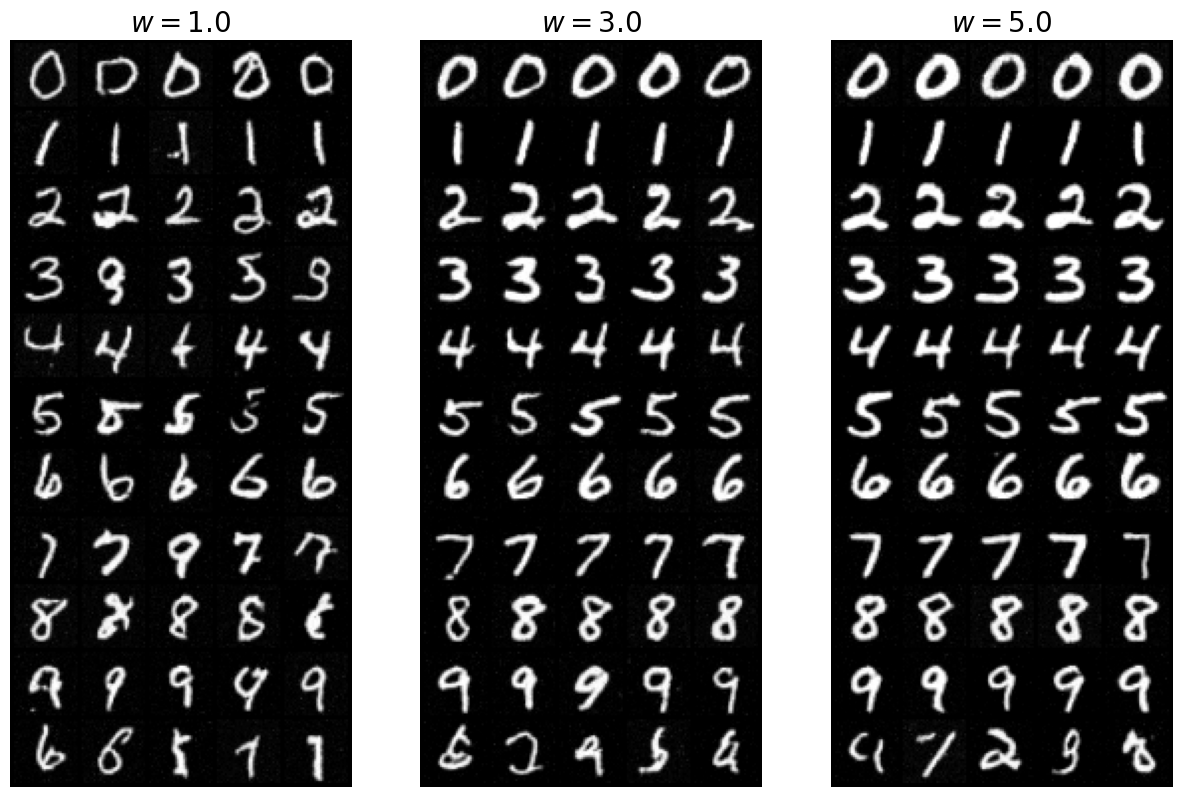

In [5]:
num_timesteps = 10
samples_per_class = 5
guidance_scales = [1.0, 3.0, 5.0]

y = (
    torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    .repeat_interleave(samples_per_class)
    .to(device)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(guidance_scales),
    figsize=(samples_per_class * len(guidance_scales), 10),
)

x0, _ = path.p_simple.sample(y.shape[0])
# (num_samples, 1, 32, 32)

for idx, w in enumerate(guidance_scales):
    flow_generator = ScoreGenerator(
        path=path,
        backbone=backbone,
        num_timesteps=num_timesteps,
        null_class=sampeable.num_classes,
        guidance_scale=w,
        device=device,
    )

    x1 = flow_generator.generate(y)

    grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(-1, 1))
    axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    axes[idx].axis("off")
    axes[idx].set_title(f"$w={w:.1f}$", fontsize=20)

plt.show()